In [151]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


eco = pd.read_csv('Economy.csv')
bus = pd.read_csv('Business.csv')

print(eco.shape)
print("------------------------------")
print(eco.head())
print("------------------------------")
print(eco.dtypes)
print("------------------------------")
print(eco.isnull().sum())
print("------------------------------")
print(eco.duplicated().sum())

(206774, 11)
------------------------------
         date   airline ch_code  num_code dep_time   from time_taken  \
0  11-02-2022  SpiceJet      SG      8709    18:55  Delhi    02h 10m   
1  11-02-2022  SpiceJet      SG      8157    06:20  Delhi    02h 20m   
2  11-02-2022   AirAsia      I5       764    04:25  Delhi    02h 10m   
3  11-02-2022   Vistara      UK       995    10:20  Delhi    02h 15m   
4  11-02-2022   Vistara      UK       963    08:50  Delhi    02h 20m   

        stop arr_time      to  price  
0  non-stop     21:05  Mumbai  5,953  
1  non-stop     08:40  Mumbai  5,953  
2  non-stop     06:35  Mumbai  5,956  
3  non-stop     12:35  Mumbai  5,955  
4  non-stop     11:10  Mumbai  5,955  
------------------------------
date          object
airline       object
ch_code       object
num_code       int64
dep_time      object
from          object
time_taken    object
stop          object
arr_time      object
to            object
price         object
dtype: object
-------------

In [152]:
print(bus.shape)
print("------------------------------")
print(bus.head())
print("------------------------------")
print(bus.dtypes)
print("------------------------------")
print(bus.isnull().sum())
print("------------------------------")
print(bus.duplicated().sum())

(93487, 11)
------------------------------
         date    airline ch_code  num_code dep_time   from time_taken  \
0  11-02-2022  Air India      AI       868    18:00  Delhi    02h 00m   
1  11-02-2022  Air India      AI       624    19:00  Delhi    02h 15m   
2  11-02-2022  Air India      AI       531    20:00  Delhi    24h 45m   
3  11-02-2022  Air India      AI       839    21:25  Delhi    26h 30m   
4  11-02-2022  Air India      AI       544    17:15  Delhi    06h 40m   

                                                stop arr_time      to   price  
0                                          non-stop     20:00  Mumbai  25,612  
1                                          non-stop     21:15  Mumbai  25,612  
2  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...    20:45  Mumbai  42,220  
3  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...    23:55  Mumbai  44,450  
4  1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...    23:55  Mumbai  46,690  
------------------------------
date   

In [153]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,2022-02-11,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,5953,Economy
1,2022-02-11,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,5953,Economy
2,2022-02-11,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,5956,Economy
3,2022-02-11,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,5955,Economy
4,2022-02-11,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,5955,Economy


In [154]:
df.describe()

,date,num_code,price
count,300261,300261.000000,300261.000000
mean,2022-03-08 00:06:26.447790592,1417.771709,20883.717666
min,2022-02-11 00:00:00,101.000000,1105.000000
25%,2022-02-25 00:00:00,637.000000,4783.000000
50%,2022-03-08 00:00:00,818.000000,7425.000000
75%,2022-03-20 00:00:00,927.000000,42521.000000
max,2022-03-31 00:00:00,9991.000000,123071.000000
std,NaN,1974.514439,22695.911266


In [155]:
bus['price'] = bus['price'].astype(str).str.replace(',', '').str.strip()
bus['price'] = pd.to_numeric(bus['price'], errors='coerce')

bus['stop'] = bus['stop'].astype(str).str.split('\n').str[0].str.strip()

print(bus['price'].dtype)
print(bus['stop'].unique())

int64
['non-stop' '1-stop' '2+-stop']


In [156]:
eco['class'] = 'Economy'
bus['class'] = 'Business'

df = pd.concat([eco, bus], ignore_index=True)

print(df.shape)
print(df['class'].value_counts())

(300261, 12)
class
Economy     206774
Business     93487
Name: count, dtype: int64


In [157]:
print(df['price'].unique()[:10])

df['price'] = df['price'].astype(str).str.replace(',', '').str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(df['price'].dtype)
print(df['price'].isnull().sum())

['5,953' '5,956' '5,955' '6,060' '5,954' '5,949' '6,165' '6,690' '6,585'
 '8,869']
int64
0


In [158]:
# Чистим stop во всём df
df['stop'] = df['stop'].astype(str).str.split('\n').str[0].str.strip()
print(df['stop'].unique())

# Конвертируем date
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
print(df['date'].dtype)
print(df['date'].min(), '—', df['date'].max())

['non-stop' '1-stop' '2+-stop']
datetime64[ns]
2022-02-11 00:00:00 — 2022-03-31 00:00:00


In [159]:
# Средняя цена по авиакомпаниям и классу
avg_price = df.groupby(['airline', 'class'])['price'].mean().reset_index()
avg_price = avg_price.sort_values('price', ascending=False)

print(avg_price)

     airline     class         price
8    Vistara  Business  55477.027777
0  Air India  Business  47131.039212
9    Vistara   Economy   7806.943645
1  Air India   Economy   7313.730144
5   SpiceJet   Economy   6179.278881
3   GO FIRST   Economy   5651.930578
4     Indigo   Economy   5324.216303
6    StarAir   Economy   4932.655738
2    AirAsia   Economy   4091.072742
7     Trujet   Economy   3244.634146


In [160]:
df['price'] = df['price'].astype(str).str.replace(',', '').str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(df['price'].dtype)
print(df['price'].isnull().sum())

int64
0


In [175]:
df.groupby(['airline', 'class'])['price']

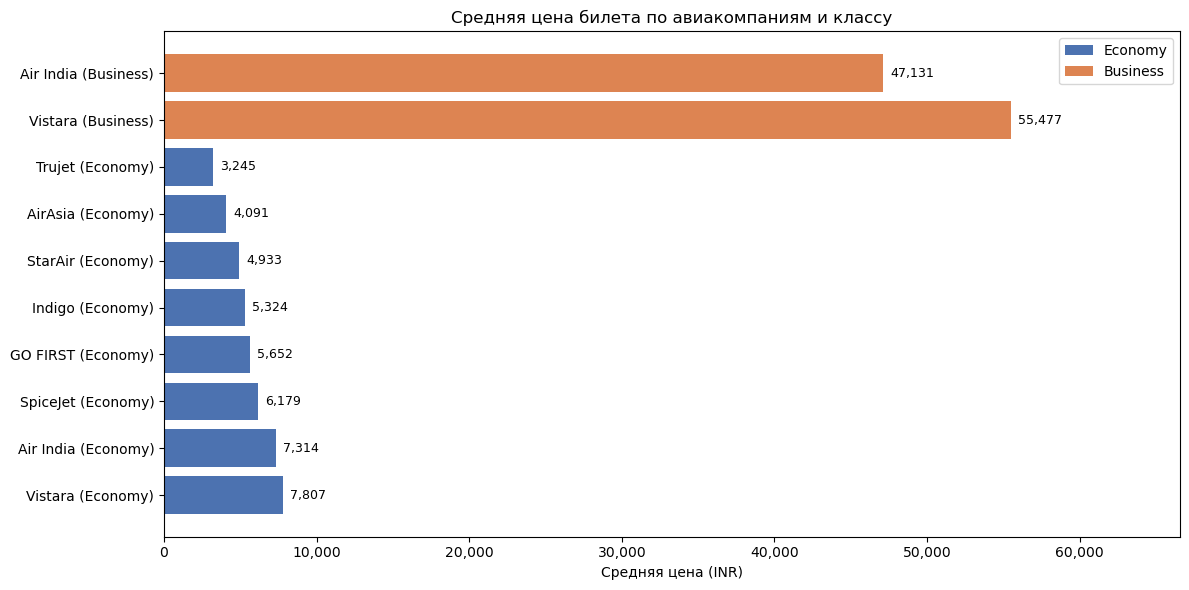

In [179]:
avg_price = df.groupby(['airline', 'class'])['price'].mean().reset_index()
avg_price = avg_price.sort_values('price', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

colors = {'Economy': '#4C72B0', 'Business': '#DD8452'}

for cls in ['Economy', 'Business']:
    subset = avg_price[avg_price['class'] == cls]
    bars = ax.barh(subset['airline'] + f' ({cls})', subset['price'],
                   color=colors[cls], label=cls)
    ax.bar_label(bars, fmt=lambda x: f'{x:,.0f}', padding=5, fontsize=9)

ax.set_xlabel('Средняя цена (INR)')
ax.set_title('Средняя цена билета по авиакомпаниям и классу')
ax.legend()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, avg_price['price'].max() * 1.2)
plt.tight_layout()
plt.savefig('avg_price_by_airline.png', dpi=150)
plt.show()

In [162]:
print(df.columns.tolist())

['date', 'airline', 'ch_code', 'num_code', 'dep_time', 'from', 'time_taken', 'stop', 'arr_time', 'to', 'price', 'class']


In [163]:
print(df['from'].unique())
print(df['to'].unique())
print(df.groupby(['from', 'to']).size().reset_index(name='count').sort_values('count', ascending=False).head(10))

['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
         from         to  count
14      Delhi     Mumbai  15291
27     Mumbai      Delhi  14809
10      Delhi  Bangalore  14012
1   Bangalore      Delhi  13756
4   Bangalore     Mumbai  12940
25     Mumbai  Bangalore  12885
29     Mumbai    Kolkata  12602
13      Delhi    Kolkata  11934
24    Kolkata     Mumbai  11467
11      Delhi    Chennai  10780


In [184]:
route.groupby(['date', 'class'])['price'].mean().reset_index()

,date,class,price
0,2022-02-11,Business,59093.000000
1,2022-02-11,Economy,13425.686441
2,2022-02-12,Business,51139.238636
3,2022-02-12,Economy,12118.398496
4,2022-02-13,Business,52438.241758
...,...,...,...
93,2022-03-29,Economy,4299.409756
94,2022-03-30,Business,43144.292453
95,2022-03-30,Economy,4307.137931
96,2022-03-31,Business,43301.883929


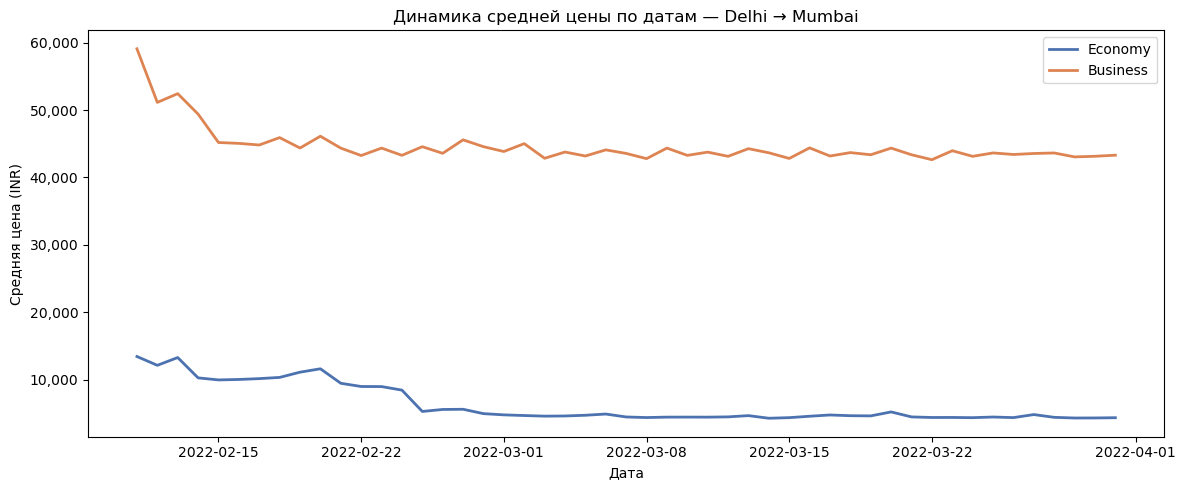

In [164]:
# Фильтруем топ маршрут
route = df[(df['from'] == 'Delhi') & (df['to'] == 'Mumbai')]

# Средняя цена по дате и классу
price_by_date = route.groupby(['date', 'class'])['price'].mean().reset_index()

# График
fig, ax = plt.subplots(figsize=(12, 5))

for cls, color in [('Economy', '#4C72B0'), ('Business', '#DD8452')]:
    subset = price_by_date[price_by_date['class'] == cls]
    ax.plot(subset['date'], subset['price'], label=cls, color=color, linewidth=2)2
ax.set_title('Динамика средней цены по датам — Delhi → Mumbai')
ax.set_xlabel('Дата')
ax.set_ylabel('Средняя цена (INR)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('price_dynamics_delhi_mumbai.png', dpi=150)
plt.show()

На маршруте Delhi → Mumbai цены в начале периода бронирования в 2–3× выше чем в середине. Эконом падает с 13 000 до 5 000 INR, бизнес — с 60 000 до 43 000 INR. Раннее бронирование не всегда выгодно — оптимальное окно покупки: 3–5 недель до вылета.

In [165]:
# цена по количеству пересадок
avg_by_stop = df.groupby(['stop', 'class'])['price'].mean().reset_index()
print(avg_by_stop.sort_values('price', ascending=False))

       stop     class         price
2   2+-stop  Business  70127.660203
0    1-stop  Business  54687.377156
4  non-stop  Business  27846.339052
3   2+-stop   Economy   9141.545678
1    1-stop   Economy   6812.298721
5  non-stop   Economy   4010.662157


Non-stop в бизнесе в 2.5× дешевле чем 2+ пересадки (27 846 vs 70 127)
В экономе та же логика: non-stop дешевле в 2.3× чем 2+ пересадки
Это контринтуитивно — обычно думают что прямой рейс дороже

Объяснение: рейсы с пересадками часто летят неудобными маршрутами или в неудобное время — авиакомпании компенсируют это ценой.

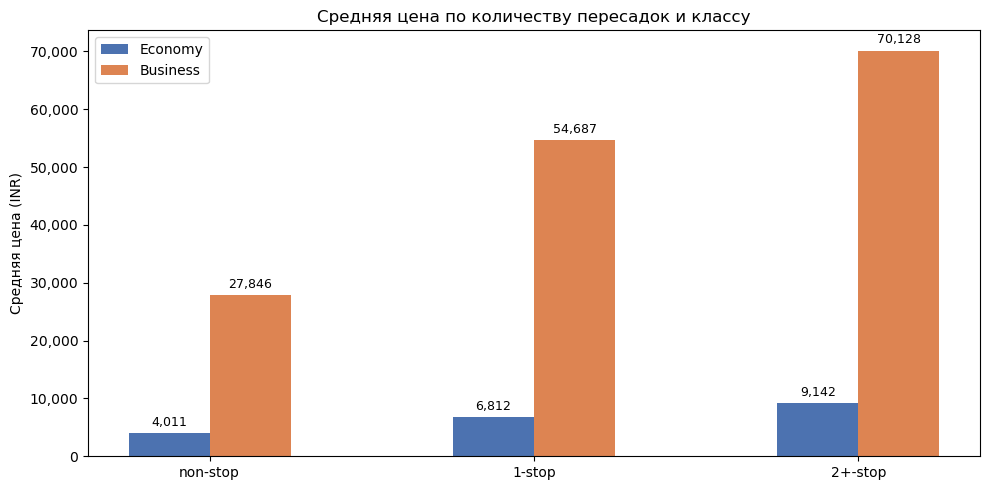

In [185]:
fig, ax = plt.subplots(figsize=(10, 5))

stop_order = ['non-stop', '1-stop', '2+-stop']
colors = {'Economy': '#4C72B0', 'Business': '#DD8452'}
x = range(len(stop_order))
width = 0.25

for i, cls in enumerate(['Economy', 'Business']):
    subset = avg_by_stop[avg_by_stop['class'] == cls].set_index('stop').reindex(stop_order)
    bars = ax.bar([xi + i * width for xi in x], subset['price'],
                  width=width, label=cls, color=colors[cls])
    ax.bar_label(bars, fmt=lambda v: f'{v:,.0f}', padding=3, fontsize=9)

ax.set_xticks([xi + width / 2 for xi in x])
ax.set_xticklabels(stop_order)
ax.set_title('Средняя цена по количеству пересадок и классу')
ax.set_ylabel('Средняя цена (INR)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('price_by_stops.png', dpi=150)
plt.show()

Отличный график, всё читается чётко.
Инсайт для README:

Прямые рейсы дешевле рейсов с пересадками — в 2.3 раза в экономе (4 011 vs 9 142 INR) и в 2.5 раз в бизнесе (27 846 vs 70 128 INR). Пассажир платит больше не за комфорт, а за неудобство маршрута.

In [167]:
df.to_csv('flights.csv', index=False)
print('Сохранено:', df.shape)

Сохранено: (300261, 12)


In [168]:
import sqlite3

conn = sqlite3.connect('flights.db')
df.to_sql('flights', conn, if_exists='replace', index=False)

# Проверяем
result = pd.read_sql('SELECT COUNT(*) as total FROM flights', conn)
print(result)

    total
0  300261


### Гипотеза №1 - цены в группе A статистически выше чем в группе B
1. **Группа A — билеты купленные в первые 7 дней периода (11–17 февраля)**
2. **Группа B — билеты купленные в последние 7 дней (25–31 марта)**

In [169]:
# Группа A — первые 7 дней
group_a = df[
    (df['date'] >= '2022-02-11') & 
    (df['date'] <= '2022-02-17') &
    (df['class'] == 'Economy')
]['price']

# Группа B — последние 7 дней
group_b = df[
    (df['date'] >= '2022-03-25') & 
    (df['date'] <= '2022-03-31') &
    (df['class'] == 'Economy')
]['price']

print(f'Группа A (ранние даты): n = {len(group_a)}, mean = {group_a.mean():,.0f} INR')
print(f'Группа B (поздние даты): n = {len(group_b)}, mean = {group_b.mean():,.0f} INR')

Группа A (ранние даты): n = 21577, mean = 11,631 INR
Группа B (поздние даты): n = 30335, mean = 4,792 INR


In [170]:
# T-тест
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f't-статистика: {t_stat:.2f}')
print(f'p-value: {p_value:.10f}')

if p_value < 0.05:
    print('Разница статистически значима — гипотеза подтверждена')
else:
    print('Разница не значима')

t-статистика: 229.10
p-value: 0.0000000000
Разница статистически значима — гипотеза подтверждена


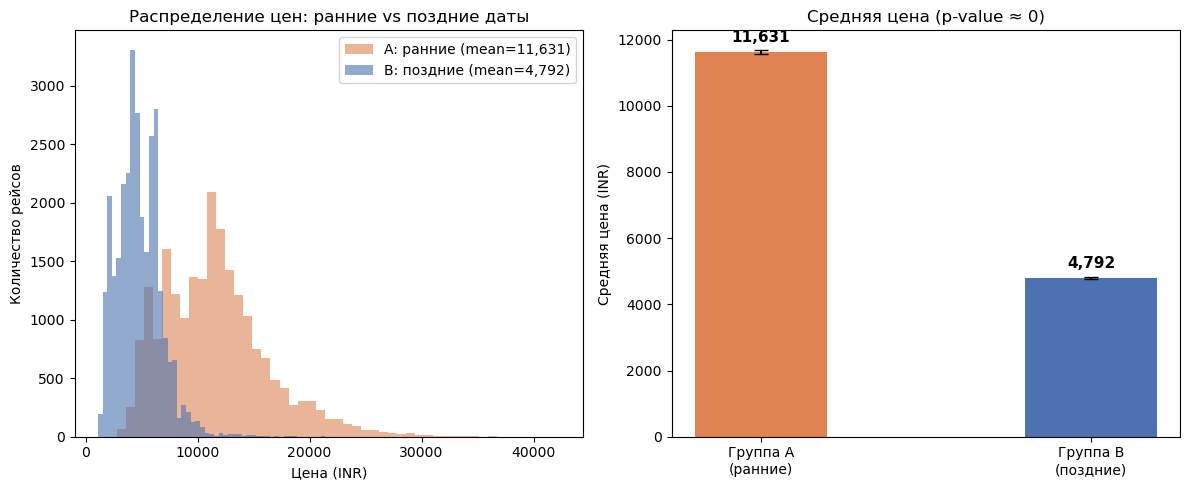

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1 — распределение цен
axes[0].hist(group_a, bins=50, alpha=0.6, color='#DD8452', label=f'A: ранние (mean={group_a.mean():,.0f})')
axes[0].hist(group_b, bins=50, alpha=0.6, color='#4C72B0', label=f'B: поздние (mean={group_b.mean():,.0f})')
axes[0].set_title('Распределение цен: ранние vs поздние даты')
axes[0].set_xlabel('Цена (INR)')
axes[0].set_ylabel('Количество рейсов')
axes[0].legend()

# График 2 — средние с доверительным интервалом
means = [group_a.mean(), group_b.mean()]
errors = [group_a.sem() * 1.96, group_b.sem() * 1.96]
bars = axes[1].bar(['Группа A\n(ранние)', 'Группа B\n(поздние)'], 
                    means, yerr=errors, 
                    color=['#DD8452', '#4C72B0'],
                    capsize=5, width=0.4)
for bar, val in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 200,
                f'{val:,.0f}', ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='black')
axes[1].set_title(f'Средняя цена (p-value ≈ 0)')
axes[1].set_ylabel('Средняя цена (INR)')

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150)
plt.show()